# Regresión Lineal Múltiple, Polinómica y Ecuación Normal
## Predicción de Consumo de Energía de Electrodomésticos

**Dataset:** Appliances Energy Prediction  
**Fuente:** https://www.kaggle.com/datasets/loveall/appliances-energy-prediction

## Variable objetivo (Y)
`Appliances` — Consumo de energía de electrodomésticos en Wh

## Features seleccionadas (n=28)

| # | Feature | Descripción | Justificación |
|---|---|---|---|
| 1 | `lights` | Consumo de luces en Wh | Cuando hay actividad en casa suben luces y electrodomésticos juntos |
| 2 | `T1` | Temperatura cocina en °C | Si hace frío se usa más horno y calefacción |
| 3 | `RH_1` | Humedad relativa cocina en % | La humedad afecta el confort y uso de climatización |
| 4 | `T2` | Temperatura sala en °C | La sala es el área de mayor actividad del hogar |
| 5 | `RH_2` | Humedad relativa sala en % | Humedad de la zona principal de la casa |
| 6 | `T3` | Temperatura cuarto de lavado en °C | Zona de uso de electrodomésticos de alto consumo |
| 7 | `RH_3` | Humedad cuarto de lavado en % | Alta humedad indica uso de lavadora o secadora |
| 8 | `T4` | Temperatura oficina en °C | Zona con computadoras y equipos encendidos |
| 9 | `RH_4` | Humedad oficina en % | Condición ambiental de la zona de trabajo |
| 10 | `T5` | Temperatura baño en °C | Indica uso de ducha caliente y calefactor |
| 11 | `RH_5` | Humedad baño en % | Alta humedad indica ducha activa — extractor encendido |
| 12 | `T6` | Temperatura exterior norte en °C | Temperatura del lado norte exterior de la casa |
| 13 | `RH_6` | Humedad exterior norte en % | Condición climática exterior |
| 14 | `T7` | Temperatura cuarto de plancha en °C | Zona de uso de plancha — electrodoméstico de alto consumo |
| 15 | `RH_7` | Humedad cuarto de plancha en % | Condición ambiental del cuarto de plancha |
| 16 | `T8` | Temperatura habitación adolescentes en °C | Zona con televisión, computadora y cargadores |
| 17 | `RH_8` | Humedad habitación adolescentes en % | Condición ambiental de la habitación |
| 18 | `T9` | Temperatura habitación padres en °C | Zona con televisión y climatización nocturna |
| 19 | `RH_9` | Humedad habitación padres en % | Condición ambiental de la habitación principal |
| 20 | `T_out` | Temperatura exterior en °C | Cuando baja la temperatura exterior sube la calefacción |
| 21 | `RH_out` | Humedad exterior en % | Condición climática exterior general |
| 22 | `Press_mm_hg` | Presión atmosférica en mmHg | La presión influye en la eficiencia de los sistemas de climatización |
| 23 | `Windspeed` | Velocidad del viento en m/s | El viento aumenta la pérdida de calor de la casa |
| 24 | `Visibility` | Visibilidad en km | Indicador de condiciones climáticas generales |
| 25 | `Tdewpoint` | Punto de rocío en °C | Indica la humedad real del ambiente exterior |
| 26 | `hour` | Hora del día (0-23) | De madrugada el consumo es mínimo — en horas de actividad sube |
| 27 | `day_of_week` | Día de la semana (0=Lunes, 6=Domingo) | Los fines de semana hay más personas en casa todo el día |
| 28 | `month` | Mes del año (1-12) | En invierno sube la calefacción — en verano el aire acondicionado |

## Columnas descartadas

| Columna | Razón |
|---|---|
| `date` | Texto — se usa solo para extraer hour, day_of_week y month |
| `rv1` | Variable aleatoria sin relación con el consumo |
| `rv2` | Variable aleatoria sin relación con el consumo |

## Tres modelos implementados
1. **Regresión Lineal Múltiple** con Descenso por Gradiente
2. **Regresión Polinómica** con Descenso por Gradiente
3. **Ecuación Normal** — solución exacta sin iteraciones

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga del Dataset

Se carga el dataset usando Pandas. Se extraen variables
temporales desde la columna date: hour, day_of_week y month.
Se descartan rv1 y rv2 por ser variables aleatorias sin
relación con el consumo de energía.

In [3]:
# Cargar dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/KAG_energydata_complete.csv')

# Extraer variables temporales desde la fecha
data['date'] = pd.to_datetime(data['date'])
data['hour']        = data['date'].dt.hour
data['day_of_week'] = data['date'].dt.dayofweek
data['month']       = data['date'].dt.month

# Definir features y variable objetivo
FEATURES = [
    'lights',
    'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3',
    'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6',
    'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9',
    'T_out', 'RH_out', 'Press_mm_hg',
    'Windspeed', 'Visibility', 'Tdewpoint',
    'hour', 'day_of_week', 'month'
]

TARGET = 'Appliances'

# Extraer X e y
X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64)
m = y.size

print(f'Dimensiones dataset : {data.shape}')
print(f'X shape             : {X.shape}')
print(f'y shape             : {y.shape}')
print(f'm                   : {m:,}')
print(f'n features          : {len(FEATURES)}')

Dimensiones dataset : (19735, 32)
X shape             : (19735, 28)
y shape             : (19735,)
m                   : 19,735
n features          : 28


## 2. Exploración del Dataset

Se revisan estadísticas básicas para entender la distribución
de los datos antes de entrenar cualquier modelo.

In [4]:
print('=== Información general ===')
data.info()
print()
print('=== Estadísticas básicas ===')
data[FEATURES + [TARGET]].describe()

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-nu

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T_out,RH_out,Press_mm_hg,Windspeed,Visibility,Tdewpoint,hour,day_of_week,month,Appliances
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,19.592106,...,7.411665,79.750418,755.522602,4.039752,38.330834,3.760707,11.502002,2.977249,3.101647,97.694958
std,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,1.844623,...,5.317409,14.901088,7.399441,2.451221,11.794719,4.194648,6.921953,1.985617,1.339200,102.524891
min,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,15.330000,...,-5.000000,24.000000,729.300000,0.000000,1.000000,-6.600000,0.000000,0.000000,1.000000,10.000000
25%,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,18.277500,...,3.666667,70.333333,750.933333,2.000000,29.000000,0.900000,6.000000,1.000000,2.000000,50.000000
50%,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,19.390000,...,6.916667,83.666667,756.100000,3.666667,40.000000,3.433333,12.000000,3.000000,3.000000,60.000000
75%,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,20.619643,...,10.408333,91.666667,760.933333,5.500000,40.000000,6.566667,17.000000,5.000000,4.000000,100.000000
max,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,25.795000,...,26.100000,100.000000,772.300000,14.000000,66.000000,15.500000,23.000000,6.000000,5.000000,1080.000000


## 3. División Entrenamiento y Validación

Se divide el dataset en 80% entrenamiento y 20% validación.

El modelo aprende con los datos de entrenamiento.
La validación permite evaluar qué tan bien generaliza
el modelo con datos que nunca vio durante el entrenamiento.

- **Entrenamiento:** 80% de los datos
- **Validación:** 20% de los datos

In [5]:
np.random.seed(42)

# Mezclar indices aleatoriamente
indices = np.random.permutation(m)

# 80% entrenamiento, 20% validacion
split    = int(0.8 * m)
idx_train = indices[:split]
idx_val   = indices[split:]

X_train = X[idx_train]
y_train = y[idx_train]
X_val   = X[idx_val]
y_val   = y[idx_val]

m_train = len(y_train)
m_val   = len(y_val)

print(f'Ejemplos entrenamiento : {m_train:,}')
print(f'Ejemplos validacion    : {m_val:,}')

Ejemplos entrenamiento : 15,788
Ejemplos validacion    : 3,947


## 4. Normalización de Características

Las features tienen escalas muy diferentes:
- Temperatura: entre 0°C y 30°C
- Humedad: entre 0% y 100%
- Presión: alrededor de 760 mmHg

Sin normalizar el descenso por gradiente converge
muy lento o diverge.

Se aplica normalización Z-score:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Se calcula μ y σ únicamente con datos de entrenamiento
para no contaminar la validación.

In [6]:
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizar con datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar mismos mu y sigma a validacion
X_val_norm = (X_val - mu) / sigma

print('Media (debe ser ≈ 0):')
print(np.mean(X_train_norm, axis=0).round(4))
print()
print('Desv. estandar (debe ser ≈ 1):')
print(np.std(X_train_norm, axis=0).round(4))

Media (debe ser ≈ 0):
[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0.  0.  0.  0.  0. -0.  0. -0.  0.]

Desv. estandar (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


## 5. Término de Intersección

Se agrega columna de unos para incluir θ₀ en el modelo:

$$h_\theta(x) = \theta_0 + \theta_1x_1 + \cdots + \theta_{28}x_{28} = \theta^Tx$$

In [7]:
# Agregar columna de unos a entrenamiento y validacion
X_train = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_val   = np.concatenate([np.ones((m_val,   1)), X_val_norm],   axis=1)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')

X_train shape: (15788, 29)
X_val shape  : (3947, 29)


## 6. Función de Costo

Mide qué tan mal predice el modelo:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Con theta = ceros el modelo no sabe nada — ese es el costo máximo.

In [9]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# Costo inicial con theta = ceros
theta = np.zeros(X_train.shape[1])
J     = computeCostMulti(X_train, y_train, theta)
print('Con theta = ceros')
print('Costo inicial = %.2f' % J)

Con theta = ceros
Costo inicial = 10061.06


## 7. Modelo 1 — Regresión Lineal Múltiple con Descenso por Gradiente

Se minimiza J(θ) actualizando theta en cada iteración:

$$\theta := \theta - \frac{\alpha}{m} X^T(X\theta - y)$$

- **α = 0.1** — tasa de aprendizaje
- **400 iteraciones**
- **theta inicial = ceros**

In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m     = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [11]:
alpha     = 0.1
num_iters = 400
theta     = np.zeros(X_train.shape[1])

theta_gd, J_history = gradientDescentMulti(X_train, y_train, theta, alpha, num_iters)

J_train = computeCostMulti(X_train, y_train, theta_gd)
J_val   = computeCostMulti(X_val,   y_val,   theta_gd)

print('=== Regresión Lineal Múltiple ===')
print('Costo inicial      : %.2f' % J_history[0])
print('Costo entrenamiento: %.2f' % J_train)
print('Costo validacion   : %.2f' % J_val)

=== Regresión Lineal Múltiple ===
Costo inicial      : 8976.76
Costo entrenamiento: 4414.88
Costo validacion   : 4251.24


## 8. Gráfica de Convergencia — Regresión Lineal Múltiple

Una curva que baja suavemente y se aplana confirma
que el modelo convergió correctamente con el alpha elegido.

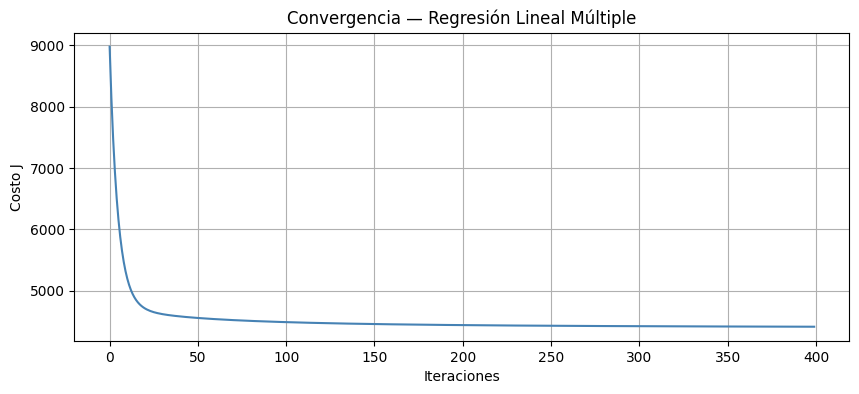

In [12]:
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(len(J_history)), J_history, color='steelblue')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia — Regresión Lineal Múltiple')
pyplot.grid(True)
pyplot.show()

## 9. Modelo 2 — Regresión Polinómica

La regresión lineal asume una relación recta entre
features y Y. Pero el consumo de energía puede tener
relaciones no lineales — por ejemplo el consumo no
sube de forma proporcional con la temperatura sino
que puede dispararse exponencialmente con el frío.

La regresión polinómica agrega las features elevadas
al cuadrado para capturar esas curvas:

$$h_\theta(x) = \theta_0 + \theta_1x_1 + \theta_2x_1^2 + \theta_3x_2 + \theta_4x_2^2 + \cdots$$

Se agregan las features al cuadrado a la matriz X.

In [13]:
# Agregar features al cuadrado — igual que el notebook del inge
X_train_pol = np.concatenate([X_train, X_train[:, 1:] ** 2], axis=1)
X_val_pol   = np.concatenate([X_val,   X_val[:,   1:] ** 2], axis=1)

print(f'X_train polinomico shape: {X_train_pol.shape}')
print(f'X_val   polinomico shape: {X_val_pol.shape}')

X_train polinomico shape: (15788, 57)
X_val   polinomico shape: (3947, 57)


In [14]:
alpha_pol     = 0.01
num_iters_pol = 400
theta_pol     = np.zeros(X_train_pol.shape[1])

theta_pol, J_history_pol = gradientDescentMulti(
    X_train_pol, y_train, theta_pol, alpha_pol, num_iters_pol
)

J_train_pol = computeCostMulti(X_train_pol, y_train, theta_pol)
J_val_pol   = computeCostMulti(X_val_pol,   y_val,   theta_pol)

print('=== Regresión Polinómica ===')
print('Costo inicial      : %.2f' % J_history_pol[0])
print('Costo entrenamiento: %.2f' % J_train_pol)
print('Costo validacion   : %.2f' % J_val_pol)

=== Regresión Polinómica ===
Costo inicial      : 7656.35
Costo entrenamiento: 4594.04
Costo validacion   : 4490.84


## 10. Gráfica de Convergencia — Regresión Polinómica

Se compara la convergencia del modelo polinómico
contra el lineal para ver cuál reduce más el costo.

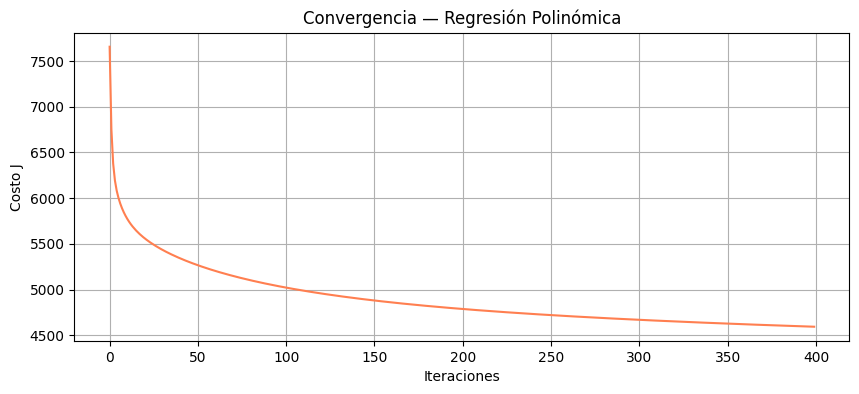

In [15]:
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(len(J_history_pol)), J_history_pol, color='coral')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia — Regresión Polinómica')
pyplot.grid(True)
pyplot.show()

## 11. Modelo 3 — Ecuación Normal

Calcula theta directamente sin iteraciones:

$$\theta = (X^TX)^{-1}X^Ty$$

No necesita alpha ni iteraciones.
Se usa para verificar que el descenso por gradiente
convergió al mínimo correcto.

In [16]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

theta_normal = normalEqn(X_train, y_train)

J_normal_train = computeCostMulti(X_train, y_train, theta_normal)
J_normal_val   = computeCostMulti(X_val,   y_val,   theta_normal)

print('=== Ecuación Normal ===')
print('Costo entrenamiento: %.2f' % J_normal_train)
print('Costo validacion   : %.2f' % J_normal_val)
print()
print('Comparacion:')
print('Costo gradiente    : %.2f' % J_train)
print('Costo ec. normal   : %.2f' % J_normal_train)

=== Ecuación Normal ===
Costo entrenamiento: 4396.30
Costo validacion   : 4239.51

Comparacion:
Costo gradiente    : 4414.88
Costo ec. normal   : 4396.30


## 12. Comparación de los Tres Modelos

In [17]:
print('=' * 45)
print('       COMPARACIÓN DE MODELOS')
print('=' * 45)
print(f'{"Modelo":<25} {"Train":>8} {"Val":>8}')
print('-' * 45)
print(f'{"Lineal (Gradiente)":<25} {J_train:>8.2f} {J_val:>8.2f}')
print(f'{"Polinomico":<25} {J_train_pol:>8.2f} {J_val_pol:>8.2f}')
print(f'{"Ecuacion Normal":<25} {J_normal_train:>8.2f} {J_normal_val:>8.2f}')
print('=' * 45)

       COMPARACIÓN DE MODELOS
Modelo                       Train      Val
---------------------------------------------
Lineal (Gradiente)         4414.88  4251.24
Polinomico                 4594.04  4490.84
Ecuacion Normal            4396.30  4239.51


## 13. Inferencias — 100 Predicciones

Se realizan 100 predicciones con el modelo entrenado
para demostrar su funcionamiento con datos de validación.

Se usan los mismos μ y σ del entrenamiento para normalizar.

In [18]:
# 100 predicciones sobre datos de validacion
y_pred_100 = np.dot(X_val[:100], theta_gd)

print('Real (Wh)    vs   Predicho (Wh)')
print('-' * 35)
for i in range(100):
    print('%.1f Wh      vs   %.1f Wh' % (y_val[i], y_pred_100[i]))

Real (Wh)    vs   Predicho (Wh)
-----------------------------------
100.0 Wh      vs   113.9 Wh
40.0 Wh      vs   73.5 Wh
100.0 Wh      vs   126.6 Wh
60.0 Wh      vs   119.9 Wh
50.0 Wh      vs   78.1 Wh
40.0 Wh      vs   81.8 Wh
40.0 Wh      vs   71.9 Wh
90.0 Wh      vs   114.2 Wh
50.0 Wh      vs   62.0 Wh
110.0 Wh      vs   104.9 Wh
70.0 Wh      vs   28.6 Wh
530.0 Wh      vs   146.1 Wh
60.0 Wh      vs   84.1 Wh
70.0 Wh      vs   141.1 Wh
50.0 Wh      vs   62.1 Wh
40.0 Wh      vs   90.1 Wh
150.0 Wh      vs   132.6 Wh
60.0 Wh      vs   93.6 Wh
50.0 Wh      vs   91.5 Wh
20.0 Wh      vs   91.7 Wh
50.0 Wh      vs   71.3 Wh
60.0 Wh      vs   69.7 Wh
250.0 Wh      vs   209.3 Wh
30.0 Wh      vs   81.5 Wh
120.0 Wh      vs   249.0 Wh
60.0 Wh      vs   95.8 Wh
40.0 Wh      vs   53.7 Wh
80.0 Wh      vs   134.9 Wh
40.0 Wh      vs   64.9 Wh
50.0 Wh      vs   34.7 Wh
50.0 Wh      vs   96.3 Wh
50.0 Wh      vs   131.1 Wh
40.0 Wh      vs   105.6 Wh
50.0 Wh      vs   49.6 Wh
100.0 Wh      vs   125.2 Wh
